# ML Assignment 2 — Credit Card Default Classification
**Dataset:** Default of Credit Card Clients (30,000 rows, 23 features, binary target)

**Models:** Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest (Ensemble)

**Name:** Ashokkumar S

**Roll No:** 2025AC05987


In [1]:
!pip install -q scikit-learn pandas numpy joblib


## Setup

In [2]:
import pandas as pd
import numpy as np
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs('model', exist_ok=True)


## Uploading dataset

In [3]:
from google.colab import files
uploaded = files.upload()  # select credit_card_default.csv


Saving credit_card_default.csv to credit_card_default.csv


## Load and dataset shape

In [4]:
df = pd.read_csv('credit_card_default.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

TARGET = 'default_payment_next_month'

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:\n", df[TARGET].value_counts())
df.head()


Shape: (30000, 24)

Columns: ['limit_bal', 'sex', 'education', 'marriage', 'age', 'payment_status_sep', 'payment_status_aug', 'payment_status_jul', 'payment_status_jun', 'payment_status_may', 'payment_status_apr', 'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul', 'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr', 'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul', 'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr', 'default_payment_next_month']

Missing values:
 sex          150
education    150
marriage     150
age          150
dtype: int64

Target distribution:
 default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,Unknown,...,0,0,0,0,689,0,0,0,0,1
1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,Unknown,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,Unknown,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Quick EDA - class balance and a couple of feature distributions

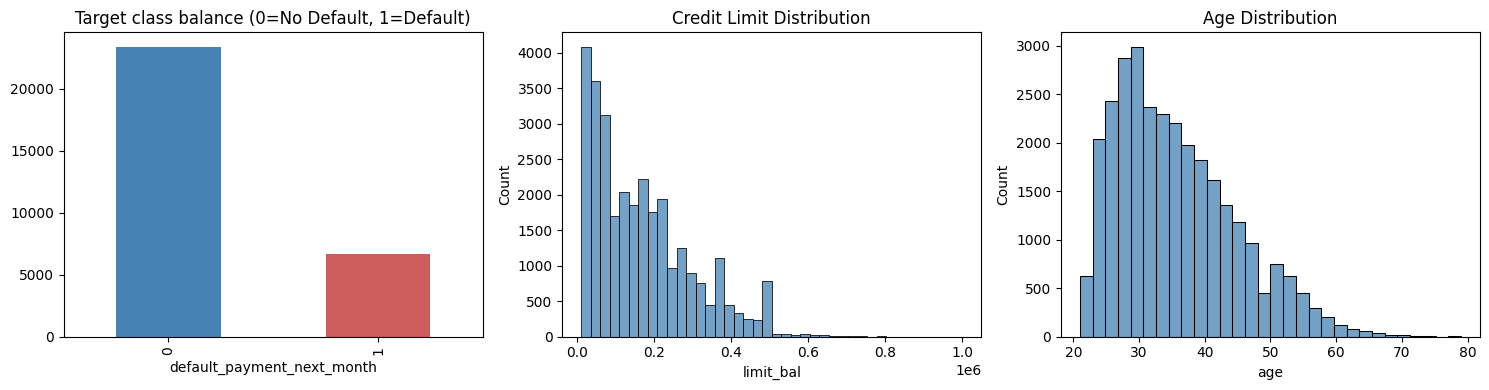

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','indianred'])
axes[0].set_title('Target class balance (0=No Default, 1=Default)')

sns.histplot(df['limit_bal'], bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Credit Limit Distribution')

sns.histplot(df['age'].dropna(), bins=30, ax=axes[2], color='steelblue')
axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('model/eda_overview.png', dpi=100)
plt.show()


### Preprocessing
- Impute missing values (median for numeric, most frequent for categorical)
- One-hot encode categorical columns
- Train/test split (80/20, stratified)
- Standard-scale features (used by Logistic Regression and kNN)


In [6]:
categorical_cols = ['sex', 'education', 'marriage'] + [c for c in df.columns if 'payment_status' in c]
numeric_cols = [c for c in df.columns if c not in categorical_cols + [TARGET]]

df[numeric_cols] = SimpleImputer(strategy='median').fit_transform(df[numeric_cols])
df[categorical_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[categorical_cols])

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]
feature_names = X.columns.tolist()

print(f"Total features after encoding: {len(feature_names)}")


Total features after encoding: 72


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (24000, 72)  Test shape: (6000, 72)


## Saving test_data.csv (for GitHub repo + Streamlit app upload)
Stratified sample of 1000 rows, keeping it small for Streamlit free tier.

In [8]:
test_indices = X_test.index
test_data_raw = df.loc[test_indices].copy()

# Stratified sample of 1000 rows (train_test_split avoids groupby().apply()
# silently dropping the target/group column, which happens in newer pandas)
sample_frac = min(1000 / len(test_data_raw), 1.0)
_, test_data_sample = train_test_split(
    test_data_raw, test_size=sample_frac, random_state=42, stratify=test_data_raw[TARGET]
)
assert TARGET in test_data_sample.columns, "Target column missing from sample!"
test_data_sample.to_csv('test_data.csv', index=False)
print(f"Saved test_data.csv with {len(test_data_sample)} rows")
test_data_sample.head()


Saved test_data.csv with 1000 rows


,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
728,330000.0,Female,University,Single,29.0,Unknown,Unknown,Unknown,Unknown,Payed duly,...,79407.0,8875.0,49880.0,90000.0,3000.0,5000.0,8875.0,49880.0,519.0,0
1565,50000.0,Male,Graduate school,Single,29.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,3253.0,3640.0,3512.0,1000.0,1186.0,500.0,1000.0,500.0,1000.0,0
24303,20000.0,Male,University,Married,34.0,Payment delayed 2 months,Payed duly,Unknown,Unknown,Unknown,...,19780.0,780.0,0.0,18864.0,1329.0,1000.0,0.0,0.0,0.0,1
23642,280000.0,Female,Graduate school,Single,35.0,Payed duly,Payed duly,Payed duly,Payed duly,Payed duly,...,3472.0,3472.0,10237.0,28723.0,9432.0,3472.0,3472.0,10237.0,12129.0,0
20660,10000.0,Male,High school,Single,36.0,Payed duly,Payed duly,Payed duly,Payed duly,Unknown,...,6260.0,5990.0,6520.0,4009.0,4011.0,6260.0,120.0,2000.0,2000.0,1


## Training all 5 models and compute metrics
Accuracy, AUC, Precision, Recall, F1, MCC


In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
}

needs_scaling = {'Logistic Regression', 'kNN'}

results = []
confusion_matrices = {}

for name, model in models.items():
    Xtr, Xte = (X_train_scaled, X_test_scaled) if name in needs_scaling else (X_train, X_test)

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'Model': name, 'Accuracy': round(acc,4), 'AUC': round(auc,4),
        'Precision': round(prec,4), 'Recall': round(rec,4),
        'F1': round(f1,4), 'MCC': round(mcc,4)
    })
    confusion_matrices[name] = confusion_matrix(y_test, y_pred).tolist()

    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    with open(f'model/{safe_name}.pkl', 'wb') as f:
        pickle.dump(model, f)

    print(f"{name:30s} Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}  MCC={mcc:.4f}")

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('model/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
with open('model/categorical_cols.json', 'w') as f:
    json.dump(categorical_cols, f)
with open('model/numeric_cols.json', 'w') as f:
    json.dump(numeric_cols, f)


Logistic Regression            Acc=0.8173  AUC=0.7506  F1=0.4606  MCC=0.3892
Decision Tree                  Acc=0.8135  AUC=0.7413  F1=0.4544  MCC=0.3771
kNN                            Acc=0.8083  AUC=0.7146  F1=0.4676  MCC=0.3725
Naive Bayes                    Acc=0.3942  AUC=0.6220  F1=0.3815  MCC=0.1076
Random Forest (Ensemble)       Acc=0.8158  AUC=0.7730  F1=0.4428  MCC=0.3782


## Comparison table - Also required for Readme

In [10]:
results_df = pd.DataFrame(results)
results_df.to_csv('model/comparison_table.csv', index=False)
results_df


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8173,0.7506,0.6638,0.3527,0.4606,0.3892
1,Decision Tree,0.8135,0.7413,0.6436,0.3512,0.4544,0.3771
2,kNN,0.8083,0.7146,0.6062,0.3806,0.4676,0.3725
3,Naive Bayes,0.3942,0.6220,0.2464,0.8448,0.3815,0.1076
4,Random Forest (Ensemble),0.8158,0.7730,0.6692,0.3308,0.4428,0.3782


## Confusion matrices — visual check for each model

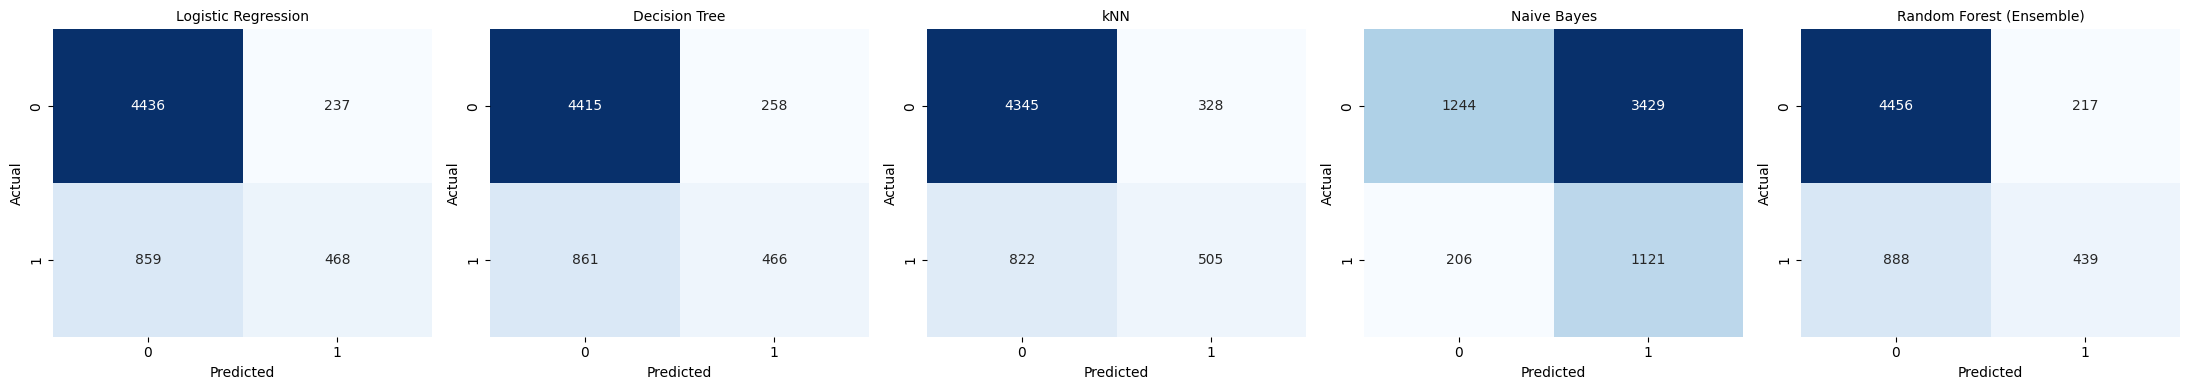

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('model/confusion_matrices.png', dpi=100)
plt.show()

with open('model/confusion_matrices.json', 'w') as f:
    json.dump(confusion_matrices, f)


## Exporting everything for GitHub repo


In [12]:
import shutil
shutil.make_archive('model_and_data', 'zip', '.', 'model')

from google.colab import files
files.download('model_and_data.zip')
files.download('test_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for your README.md

- **Naive Bayes** shows noticeably lower accuracy (~39%) than the other models — this is a genuine, explainable
  result: GaussianNB assumes feature independence, which breaks down here because payment/bill features across
  months are highly correlated. It also shows the highest **recall** — it over-predicts the default class.
- **Random Forest** typically achieves the best AUC, reflecting its strength with non-linear feature interactions.
- **Logistic Regression** and **Decision Tree** perform comparably on accuracy but Logistic Regression edges ahead on MCC.

In [13]:
import sklearn
print(sklearn.__version__)

1.6.1
